# Research Paper Summarization — LongT5 (Long-Document Baseline)



> **Dataset:** `ccdv/pubmed-summarization` (PubMed) dari Hugging Face  
> **Model:** `google/long-t5-tglobal-base` (max 4096 token input)

---
## 0. Install Dependencies

In [ ]:
from google.colab import drive

In [2]:
!pip install transformers==4.46.0 -q
print("Done! Restart kernel sekarang")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 4.5 MB/s eta 0:00:00
Reason for being yanked: This version unfortunately does not work with 3.8 but we did not drop the support yet
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 135.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 129.8 MB/s eta 0:00:00
Done! Restart kernel sekarang


In [3]:
!pip install datasets rouge-score sentencepiece accelerate -q
print('Dependencies siap!')

  Preparing metadata (setup.py) ... done
Dependencies siap!


---
## 1. Dataset Preparation

Sama seperti model lain: `ccdv/pubmed-summarization`, split train/validation/test bawaan.

In [4]:
from datasets import load_dataset
import pandas as pd

print('Loading dataset PubMed dari Hugging Face...')
print('Ref: https://huggingface.co/datasets/ccdv/pubmed-summarization')

dataset = load_dataset('ccdv/pubmed-summarization')

print('\nDataset splits tersedia:')
print(dataset)
print(f'\nJumlah data:')
print(f'  Train      : {len(dataset["train"]):,}')
print(f'  Validation : {len(dataset["validation"]):,}')
print(f'  Test       : {len(dataset["test"]):,}')


Loading dataset PubMed dari Hugging Face...
Ref: https://huggingface.co/datasets/ccdv/pubmed-summarization


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

section/train-00000-of-00005.parquet:   0%|          | 0.00/210M [00:00<?, ?B/s]

section/train-00001-of-00005.parquet:   0%|          | 0.00/208M [00:00<?, ?B/s]

...

section/test-00000-of-00001.parquet:   0%|          | 0.00/58.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/119924 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6633 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6658 [00:00<?, ? examples/s]


Dataset splits tersedia:
DatasetDict({
    train: Dataset({
        features: ['article', 'abstract'],
        num_rows: 119924
    })
    validation: Dataset({
        features: ['article', 'abstract'],
        num_rows: 6633
    })
    test: Dataset({
        features: ['article', 'abstract'],
        num_rows: 6658
    })
})

Jumlah data:
  Train      : 119,924
  Validation : 6,633
  Test       : 6,658


In [5]:
def map_columns(example):
    return {
        'input_text': example['article'],
        'target_text': example['abstract']
    }

dataset = dataset.map(map_columns, remove_columns=['article', 'abstract'])
print('Kolom setelah mapping:', dataset['train'].column_names)
print('\nContoh input_text (50 kata pertama):')
print(' '.join(dataset['train'][0]['input_text'].split()[:50]))


Map:   0%|          | 0/119924 [00:00<?, ? examples/s]

Map:   0%|          | 0/6633 [00:00<?, ? examples/s]

Map:   0%|          | 0/6658 [00:00<?, ? examples/s]

Kolom setelah mapping: ['input_text', 'target_text']

Contoh input_text (50 kata pertama):
a recent systematic analysis showed that in 2011 , 314 ( 296 - 331 ) million children younger than 5 years were mildly , moderately or severely stunted and 258 ( 240 - 274 ) million were mildly , moderately or severely underweight in the developing countries . in iran


In [6]:
DEBUG_MODE = True
DEBUG_SIZE = 6658
EVAL_SIZE  = 500

if DEBUG_MODE:
    train_data = dataset['train'].select(range(DEBUG_SIZE))
    val_data   = dataset['validation'].select(range(EVAL_SIZE))
    test_data  = dataset['test'].select(range(EVAL_SIZE))
    print(f'[DEBUG MODE] Subset kecil:')
else:
    train_data = dataset['train']
    val_data   = dataset['validation']
    test_data  = dataset['test']
    print(f'[FULL MODE] Seluruh dataset:')

print(f'  Train : {len(train_data):,}')
print(f'  Val   : {len(val_data):,}')
print(f'  Test  : {len(test_data):,}')


[DEBUG MODE] Subset kecil:
  Train : 6,658
  Val   : 500
  Test  : 500


In [7]:
import os
SAVE_PATH = './scientific_papers_pubmed'
if not os.path.exists(SAVE_PATH):
    dataset.save_to_disk(SAVE_PATH)
    print(f'Dataset disimpan ke: {SAVE_PATH}')
else:
    print(f'Dataset sudah ada di: {SAVE_PATH} — skip saving')


Saving the dataset (0/5 shards):   0%|          | 0/119924 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/6633 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/6658 [00:00<?, ? examples/s]

Dataset disimpan ke: ./scientific_papers_pubmed


---
## 2. Text Pre-processing

Sesuai proposal: Cleaning → Normalization → Tokenization.

**Keunggulan LongT5 vs BART/PEGASUS:** max input **4096 token** (bukan 1024),
sehingga lebih banyak konten artikel yang bisa diproses tanpa truncation.

In [8]:
import re

def clean_text(text):
    if isinstance(text, list):
        text = ' '.join(text)
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

sample_clean = clean_text(dataset['train'][0]['input_text'])
print('Setelah cleaning:', repr(sample_clean[:150]))


Setelah cleaning: 'a recent systematic analysis showed that in 2011 , 314 ( 296 - 331 ) million children younger than 5 years were mildly , moderately or severely stunte'


In [9]:
from transformers import AutoTokenizer

MODEL_NAME = 'google/long-t5-tglobal-base'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# ✅ LongT5 support 4096 token — jauh lebih panjang dari BART (1024)
MAX_INPUT_LENGTH  = 4096
MAX_TARGET_LENGTH = 256

print(f'Tokenizer: {MODEL_NAME}')
print(f'Max input length : {MAX_INPUT_LENGTH}')
print(f'Max target length: {MAX_TARGET_LENGTH}')
print(f'Vocab size       : {tokenizer.vocab_size:,}')


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

config.json:   0%|          | 0.00/851 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer: google/long-t5-tglobal-base
Max input length : 4096
Max target length: 256
Vocab size       : 32,100


In [10]:
def preprocess(examples):
    inputs  = [clean_text(txt) for txt in examples['input_text']]
    targets = [clean_text(txt) for txt in examples['target_text']]

    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LENGTH,
        padding='max_length',
        truncation=True
    )
    labels = tokenizer(
        text_target=targets,
        max_length=MAX_TARGET_LENGTH,
        padding='max_length',
        truncation=True
    )
    labels_ids = [
        [(l if l != tokenizer.pad_token_id else -100) for l in label]
        for label in labels['input_ids']
    ]
    model_inputs['labels'] = labels_ids
    return model_inputs

print('Preprocessing train data...')
tokenized_train = train_data.map(preprocess, batched=True, remove_columns=train_data.column_names)
print('Preprocessing validation data...')
tokenized_val = val_data.map(preprocess, batched=True, remove_columns=val_data.column_names)
print('Preprocessing test data...')
tokenized_test = test_data.map(preprocess, batched=True, remove_columns=test_data.column_names)
print(f'\nSelesai! Kolom tokenized: {tokenized_train.column_names}')


Preprocessing train data...


Map:   0%|          | 0/6658 [00:00<?, ? examples/s]

Preprocessing validation data...


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Preprocessing test data...


Map:   0%|          | 0/500 [00:00<?, ? examples/s]


Selesai! Kolom tokenized: ['input_ids', 'attention_mask', 'labels']


---
## 3. Model Training

In [11]:
import os, torch
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

from transformers import AutoModelForSeq2SeqLM, Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq

print(f'Loading model: {MODEL_NAME}')
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('Tidak ada GPU — pertimbangkan pakai Colab/Kaggle')

print(f'\nJumlah parameter model: {model.num_parameters():,}')


Loading model: google/long-t5-tglobal-base


pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Device: cuda
GPU: NVIDIA L4
VRAM: 23.7 GB

Jumlah parameter model: 296,936,064


In [12]:
training_args = Seq2SeqTrainingArguments(
    output_dir='./longt5-pubmed-results',

    num_train_epochs=3,
    learning_rate=5e-5,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,

    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LENGTH,

    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    logging_steps=10,
    save_total_limit=2,

    fp16=False,          # ✅ matiin fp16 — LongT5 tidak kompatibel
    bf16=torch.cuda.is_bf16_supported(),  # ✅ pakai bf16 kalau GPU support
    gradient_accumulation_steps=8,
    gradient_checkpointing=True,
    optim='adafactor',
    warmup_steps=100,
    weight_decay=0.01,
)

print('Training arguments configured:')
print(f'  Epochs     : {training_args.num_train_epochs}')
print(f'  LR         : {training_args.learning_rate}')
print(f'  Batch size : {training_args.per_device_train_batch_size}')
print(f'  Grad accum : {training_args.gradient_accumulation_steps}')
print(f'  Grad ckpt  : {training_args.gradient_checkpointing}')
print(f'  Optimizer  : {training_args.optim}')


Training arguments configured:
  Epochs     : 3
  LR         : 5e-05
  Batch size : 1
  Grad accum : 8
  Grad ckpt  : True
  Optimizer  : OptimizerNames.ADAFACTOR


In [13]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
)

print("Trainer baru siap!")

Trainer baru siap!


In [14]:
import torch
from transformers import AutoModelForSeq2SeqLM

# Bersihkan state lama
torch.cuda.empty_cache()

# Load ulang model fresh
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

# ✅ Pastikan model di device yang benar SEBELUM Trainer dibuat
model = model.to(device)

# Verifikasi ada floating point params
params = list(model.parameters())
print(f"Total params: {len(params)}")
print(f"Floating point params: {sum(1 for p in params if p.is_floating_point())}")
print(f"Model device: {next(model.parameters()).device}")

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Total params: 297
Floating point params: 297
Model device: cuda:0


In [15]:
torch.cuda.empty_cache()

print('Mulai training LongT5...')
print('=' * 50)

train_result = trainer.train()

print('\nTraining selesai!')
print(f'Training loss akhir: {train_result.training_loss:.4f}')
print(f'Total runtime      : {train_result.metrics["train_runtime"]:.1f} detik')


Mulai training LongT5...


wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Epoch,Training Loss,Validation Loss
0,14.601600,1.496565
1,14.610300,1.469798
2,13.928200,1.461789


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.



Training selesai!
Training loss akhir: 15.6100
Total runtime      : 14955.1 detik


In [16]:
MODEL_SAVE_PATH = './longt5-pubmed-finetuned'
model.save_pretrained(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)
print(f'Model disimpan ke: {MODEL_SAVE_PATH}')


Model disimpan ke: ./longt5-pubmed-finetuned


---
## 4. Inference — Generate Ringkasan

In [17]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

model_inf = AutoModelForSeq2SeqLM.from_pretrained('./longt5-pubmed-finetuned')
tokenizer_inf = AutoTokenizer.from_pretrained('./longt5-pubmed-finetuned')
model_inf = model_inf.to(device)
model_inf.eval()

print('Model inferensi siap!')


Model inferensi siap!


In [18]:
def generate_summary(text, max_length=256, min_length=50):
    inputs = tokenizer_inf(
        text,
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        summary_ids = model_inf.generate(
            inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            max_length=max_length,
            min_length=min_length,
            no_repeat_ngram_size=3,
            num_beams=4,
            early_stopping=True
        )
    return tokenizer_inf.decode(summary_ids[0], skip_special_tokens=True)

# Test satu sampel
sample = test_data[0]
print('--- Generated Summary ---')
print(generate_summary(sample['input_text']))
print('\n--- Reference Abstract ---')
print(sample['target_text'])


--- Generated Summary ---
given that research on healthy young adults suggests that anxiety reduces processing capacity and impairs processing efficiency , especially in the central executive and attentional systems of working memory [ 26 , 27 ] , we hypothesized that pd patients with anxiety would show impairments in attentional set - shifting and working memory compared to p d patients without anxiety . lpda+ demonstrated worse performance on the digit span forward test ( t(19 ) = 2.29 , p = 0.033 ) compared the dda group, whereas the rpd group demonstrated significantly worse lm - ii test performance ( u = 37.5 ) and logical memory % retention (  75.5 ) than the tmt group ; however , no differences were found between groups in mmse , global cognition , and mds - updrs part i , which were compared with the independent t - test or mann whitney u test , depending on whether the variable met parametric assumptions . groups were matched in age

--- Reference Abstract ---
research on the 

In [19]:
print('Generating ringkasan untuk semua test data...')

generated_summaries = []
reference_summaries = []

for i, sample in enumerate(test_data):
    gen = generate_summary(sample['input_text'])
    generated_summaries.append(gen)
    reference_summaries.append(sample['target_text'])

    if (i + 1) % 10 == 0 or (i + 1) == len(test_data):
        print(f'  Progress: {i+1}/{len(test_data)}')

print(f'\nSelesai! Total ringkasan: {len(generated_summaries)}')


Generating ringkasan untuk semua test data...
  Progress: 10/500
  Progress: 20/500
  Progress: 30/500
  Progress: 40/500
  Progress: 50/500
  Progress: 60/500
  Progress: 70/500
  Progress: 80/500
  Progress: 90/500
  Progress: 100/500
  Progress: 110/500
  Progress: 120/500
  Progress: 130/500
  Progress: 140/500
  Progress: 150/500
  Progress: 160/500
  Progress: 170/500
  Progress: 180/500
  Progress: 190/500
  Progress: 200/500
  Progress: 210/500
  Progress: 220/500
  Progress: 230/500
  Progress: 240/500
  Progress: 250/500
  Progress: 260/500
  Progress: 270/500
  Progress: 280/500
  Progress: 290/500
  Progress: 300/500
  Progress: 310/500
  Progress: 320/500
  Progress: 330/500
  Progress: 340/500
  Progress: 350/500
  Progress: 360/500
  Progress: 370/500
  Progress: 380/500
  Progress: 390/500
  Progress: 400/500
  Progress: 410/500
  Progress: 420/500
  Progress: 430/500
  Progress: 440/500
  Progress: 450/500
  Progress: 460/500
  Progress: 470/500
  Progress: 480/500
  P

---
## 5. Evaluation (ROUGE-1, ROUGE-2, ROUGE-L)

In [20]:
from rouge_score import rouge_scorer
import numpy as np

def compute_rouge(predictions, references):
    scorer = rouge_scorer.RougeScorer(
        ['rouge1', 'rouge2', 'rougeL'],
        use_stemmer=True
    )
    scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}
    for pred, ref in zip(predictions, references):
        s = scorer.score(ref, pred)
        scores['rouge1'].append(s['rouge1'].fmeasure)
        scores['rouge2'].append(s['rouge2'].fmeasure)
        scores['rougeL'].append(s['rougeL'].fmeasure)
    return {
        'ROUGE-1': round(np.mean(scores['rouge1']) * 100, 2),
        'ROUGE-2': round(np.mean(scores['rouge2']) * 100, 2),
        'ROUGE-L': round(np.mean(scores['rougeL']) * 100, 2),
    }

rouge_scores = compute_rouge(generated_summaries, reference_summaries)

print('\n' + '=' * 40)
print('      HASIL EVALUASI — LongT5')
print('=' * 40)
for metric, score in rouge_scores.items():
    print(f'  {metric} : {score:.2f}')
print('=' * 40)



      HASIL EVALUASI — LongT5
  ROUGE-1 : 31.80
  ROUGE-2 : 9.62
  ROUGE-L : 17.52


In [21]:
results_df = pd.DataFrame([{
    'Model': 'LongT5 (google/long-t5-tglobal-base)',
    'ROUGE-1': rouge_scores['ROUGE-1'],
    'ROUGE-2': rouge_scores['ROUGE-2'],
    'ROUGE-L': rouge_scores['ROUGE-L'],
    'Tipe': 'Long-Document Baseline',
    'Dataset': 'PubMed (ccdv/pubmed-summarization)',
    'Max Input Tokens': MAX_INPUT_LENGTH,
    'Test Samples': len(test_data)
}])

results_df.to_csv('longt5_rouge_results.csv', index=False)
print('Hasil disimpan ke: longt5_rouge_results.csv')
results_df


Hasil disimpan ke: longt5_rouge_results.csv


,Model,ROUGE-1,ROUGE-2,ROUGE-L,Tipe,Dataset,Max Input Tokens,Test Samples
0,LongT5 (google/long-t5-tglobal-base),31.8,9.62,17.52,Long-Document Baseline,PubMed (ccdv/pubmed-summarization),4096,500


---
## 📊 Visualisasi & Metric Evaluation

Visualisasi hasil evaluasi model: ROUGE scores, distribusi per sampel, analisis panjang, dan training curves.

In [22]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
import numpy as np
from rouge_score import rouge_scorer as rs_mod

# ── Hitung score per sampel ──
sc = rs_mod.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
per_sample = {'ROUGE-1': [], 'ROUGE-2': [], 'ROUGE-L': []}
for pred, ref in zip(generated_summaries, reference_summaries):
    s = sc.score(ref, pred)
    per_sample['ROUGE-1'].append(s['rouge1'].fmeasure * 100)
    per_sample['ROUGE-2'].append(s['rouge2'].fmeasure * 100)
    per_sample['ROUGE-L'].append(s['rougeL'].fmeasure * 100)

# ── Plot 1: ROUGE Bar Chart ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'ROUGE Evaluation — {MODEL_NAME}', fontsize=13, fontweight='bold')

metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
scores  = [rouge_scores[m] for m in metrics]
colors  = ['#4C72B0', '#DD8452', '#55A868']

bars = axes[0].bar(metrics, scores, color=colors, width=0.5, edgecolor='white')
axes[0].set_ylim(0, max(scores) * 1.35)
axes[0].set_ylabel('F1 Score (%)')
axes[0].set_title('ROUGE Scores (Average)')
axes[0].grid(True, axis='y', alpha=0.3)
for bar, score in zip(bars, scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{score:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# ── Plot 2: Distribusi ROUGE-1 (Histogram) ──
axes[1].hist(per_sample['ROUGE-1'], bins=20, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(per_sample['ROUGE-1']), color='tomato', linestyle='--',
               linewidth=2, label=f'Mean: {np.mean(per_sample["ROUGE-1"]):.2f}')
axes[1].set_xlabel('ROUGE-1 F1 Score (%)')
axes[1].set_ylabel('Jumlah Sampel')
axes[1].set_title('Distribusi ROUGE-1 per Sampel')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./viz_rouge_bar_hist.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_rouge_bar_hist.png")


Saved: viz_rouge_bar_hist.png


In [23]:
# ── Plot 3: Boxplot semua metrik ──
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title(f'Score Distribution — {MODEL_NAME}', fontsize=12, fontweight='bold')

bp = ax.boxplot(list(per_sample.values()), labels=list(per_sample.keys()),
                patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], ['#4C72B0', '#DD8452', '#55A868']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('F1 Score (%)')
ax.grid(True, axis='y', alpha=0.3)
for i, (m, vals) in enumerate(per_sample.items(), 1):
    med = np.median(vals)
    ax.text(i, med + 0.3, f'{med:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('./viz_rouge_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_rouge_boxplot.png")


Saved: viz_rouge_boxplot.png


/tmp/ipykernel_641/525352208.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(list(per_sample.values()), labels=list(per_sample.keys()),


In [24]:
# ── Plot 4: Panjang Input vs ROUGE-1 & Generated vs Reference ──
input_lengths = [len(sample['input_text'].split()) for sample in test_data]
gen_lengths   = [len(s.split()) for s in generated_summaries]
ref_lengths   = [len(s.split()) for s in reference_summaries]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Length Analysis — {MODEL_NAME}', fontsize=13, fontweight='bold')

# Scatter: input length vs ROUGE-1
axes[0].scatter(input_lengths, per_sample['ROUGE-1'], alpha=0.4, color='#4C72B0', s=18)
z = np.polyfit(input_lengths, per_sample['ROUGE-1'], 1)
x_line = np.linspace(min(input_lengths), max(input_lengths), 100)
axes[0].plot(x_line, np.poly1d(z)(x_line), color='tomato', linewidth=2,
            linestyle='--', label='Trend')
axes[0].set_xlabel('Panjang Input (kata)')
axes[0].set_ylabel('ROUGE-1 (%)')
axes[0].set_title('Panjang Input vs ROUGE-1')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bar: generated vs reference length
avg_gen, avg_ref = np.mean(gen_lengths), np.mean(ref_lengths)
bars = axes[1].bar(['Generated\nSummary', 'Reference\nAbstract'],
                   [avg_gen, avg_ref],
                   color=['#4C72B0', '#55A868'], width=0.4, edgecolor='white')
axes[1].set_ylabel('Rata-rata Panjang (kata)')
axes[1].set_title('Panjang Generated vs Reference')
axes[1].grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, [avg_gen, avg_ref]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('./viz_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_length_analysis.png")


Saved: viz_length_analysis.png


In [25]:
# ── Plot 5: Training & Validation Loss Curve ──
history = trainer.state.log_history
train_steps, train_losses, eval_epochs, eval_losses = [], [], [], []

for entry in history:
    if 'loss' in entry and 'eval_loss' not in entry:
        train_steps.append(entry['step'])
        train_losses.append(entry['loss'])
    if 'eval_loss' in entry:
        eval_epochs.append(entry['epoch'])
        eval_losses.append(entry['eval_loss'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Training Curves — {MODEL_NAME}', fontsize=13, fontweight='bold')

axes[0].plot(train_steps, train_losses, color='steelblue', linewidth=1.5)
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss per Step')
axes[0].grid(True, alpha=0.3)

if eval_losses:
    axes[1].plot(eval_epochs, eval_losses, color='tomato', linewidth=2,
                marker='o', markersize=7, label='Val Loss')
    for ep, loss in zip(eval_epochs, eval_losses):
        axes[1].annotate(f'{loss:.4f}', (ep, loss),
                        textcoords='offset points', xytext=(0, 8),
                        ha='center', fontsize=9)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Validation Loss per Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'No eval loss logged', ha='center', va='center',
                transform=axes[1].transAxes, fontsize=12, color='gray')

plt.tight_layout()
plt.savefig('./viz_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_training_curves.png")


Saved: viz_training_curves.png


---
## 6. Evaluasi Kualitatif

In [26]:
sc = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

print('=' * 60)
print('       EVALUASI KUALITATIF — LongT5')
print('=' * 60)

for idx in range(3):
    print(f'\n📄 SAMPEL #{idx+1}')
    print('-' * 60)
    print('[INPUT — 80 kata pertama]:')
    print(' '.join(test_data[idx]['input_text'].split()[:80]) + '...')
    print('\n[GENERATED SUMMARY]:')
    print(generated_summaries[idx])
    print('\n[REFERENCE ABSTRACT]:')
    print(reference_summaries[idx][:400] + '...')
    s = sc.score(reference_summaries[idx], generated_summaries[idx])
    print(f'\n[ROUGE per sampel]: R1={s["rouge1"].fmeasure*100:.1f} | R2={s["rouge2"].fmeasure*100:.1f} | RL={s["rougeL"].fmeasure*100:.1f}')
    print('-' * 60)


       EVALUASI KUALITATIF — LongT5

📄 SAMPEL #1
------------------------------------------------------------
[INPUT — 80 kata pertama]:
anxiety affects quality of life in those living with parkinson 's disease ( pd ) more so than overall cognitive status , motor deficits , apathy , and depression [ 13 ] . although anxiety and depression are often related and coexist in pd patients , recent research suggests that anxiety rather than depression is the most prominent and prevalent mood disorder in pd [ 5 , 6 ] . yet , our current understanding of anxiety and its impact...

[GENERATED SUMMARY]:
given that research on healthy young adults suggests that anxiety reduces processing capacity and impairs processing efficiency , especially in the central executive and attentional systems of working memory [ 26 , 27 ] , we hypothesized that pd patients with anxiety would show impairments in attentional set - shifting and working memory compared to p d patients without anxiety . lpda+ demonstrated

---
## 7. Simpan Hasil & Zip Output

In [30]:
import os

# Cek file yang ada
files = [f for f in os.listdir('.') if 'longt5' in f.lower() or 'rouge' in f.lower()]
print("File yang ada:", files)

File yang ada: ['viz_rouge_boxplot.png', 'longt5-pubmed-results', 'longt5_rouge_results.csv', 'longt5-pubmed-finetuned', 'viz_rouge_bar_hist.png']


In [31]:
import json

output_data = {
    'model': 'LongT5',
    'model_name': MODEL_NAME,
    'dataset': 'PubMed (ccdv/pubmed-summarization)',
    'rouge_scores': rouge_scores,
    'num_test_samples': len(test_data),
    'max_input_length': MAX_INPUT_LENGTH,
    'max_target_length': MAX_TARGET_LENGTH,
    'predictions': generated_summaries,
    'references': reference_summaries
}

with open('longt5_predictions.json', 'w') as f:
    json.dump(output_data, f, indent=2)

print('✅ longt5_predictions.json saved!')

✅ longt5_predictions.json saved!


In [32]:
from google.colab import drive
import shutil, os, glob

drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/My Drive/Binus/Semester_4/NLP/FinalProject/Result/LongT5'
os.makedirs(DRIVE_PATH, exist_ok=True)

# Simpan visualisasi
viz_files = glob.glob('./viz_*.png')
for f in viz_files:
    shutil.copy(f, DRIVE_PATH)
    print(f'  ✅ {f} → Drive')

# Simpan hasil evaluasi — nama file lowercase
shutil.copy('longt5_rouge_results.csv', DRIVE_PATH)
shutil.copy('longt5_predictions.json', DRIVE_PATH)
print(f'  ✅ longt5_rouge_results.csv → Drive')
print(f'  ✅ longt5_predictions.json → Drive')

# Simpan model weights
DRIVE_MODEL_PATH = '/content/drive/My Drive/Binus/Semester_4/NLP/FinalProject/Models/LongT5'
os.makedirs(DRIVE_MODEL_PATH, exist_ok=True)
if not os.path.exists(f'{DRIVE_MODEL_PATH}/longt5-pubmed-finetuned'):
    print("Menyimpan model weights ke Drive...")
    shutil.copytree('./longt5-pubmed-finetuned', f'{DRIVE_MODEL_PATH}/longt5-pubmed-finetuned')
    print(f'  ✅ Model weights → Drive')
else:
    print("Model weights sudah ada — skip")

print(f'\n✅ Semua hasil disimpan ke: {DRIVE_PATH}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  ✅ ./viz_rouge_boxplot.png → Drive
  ✅ ./viz_training_curves.png → Drive
  ✅ ./viz_length_analysis.png → Drive
  ✅ ./viz_rouge_bar_hist.png → Drive
  ✅ longt5_rouge_results.csv → Drive
  ✅ longt5_predictions.json → Drive
Menyimpan model weights ke Drive...
  ✅ Model weights → Drive

✅ Semua hasil disimpan ke: /content/drive/My Drive/Binus/Semester_4/NLP/FinalProject/Result/LongT5


Total visualisasi: 4

📊 Length Analysis


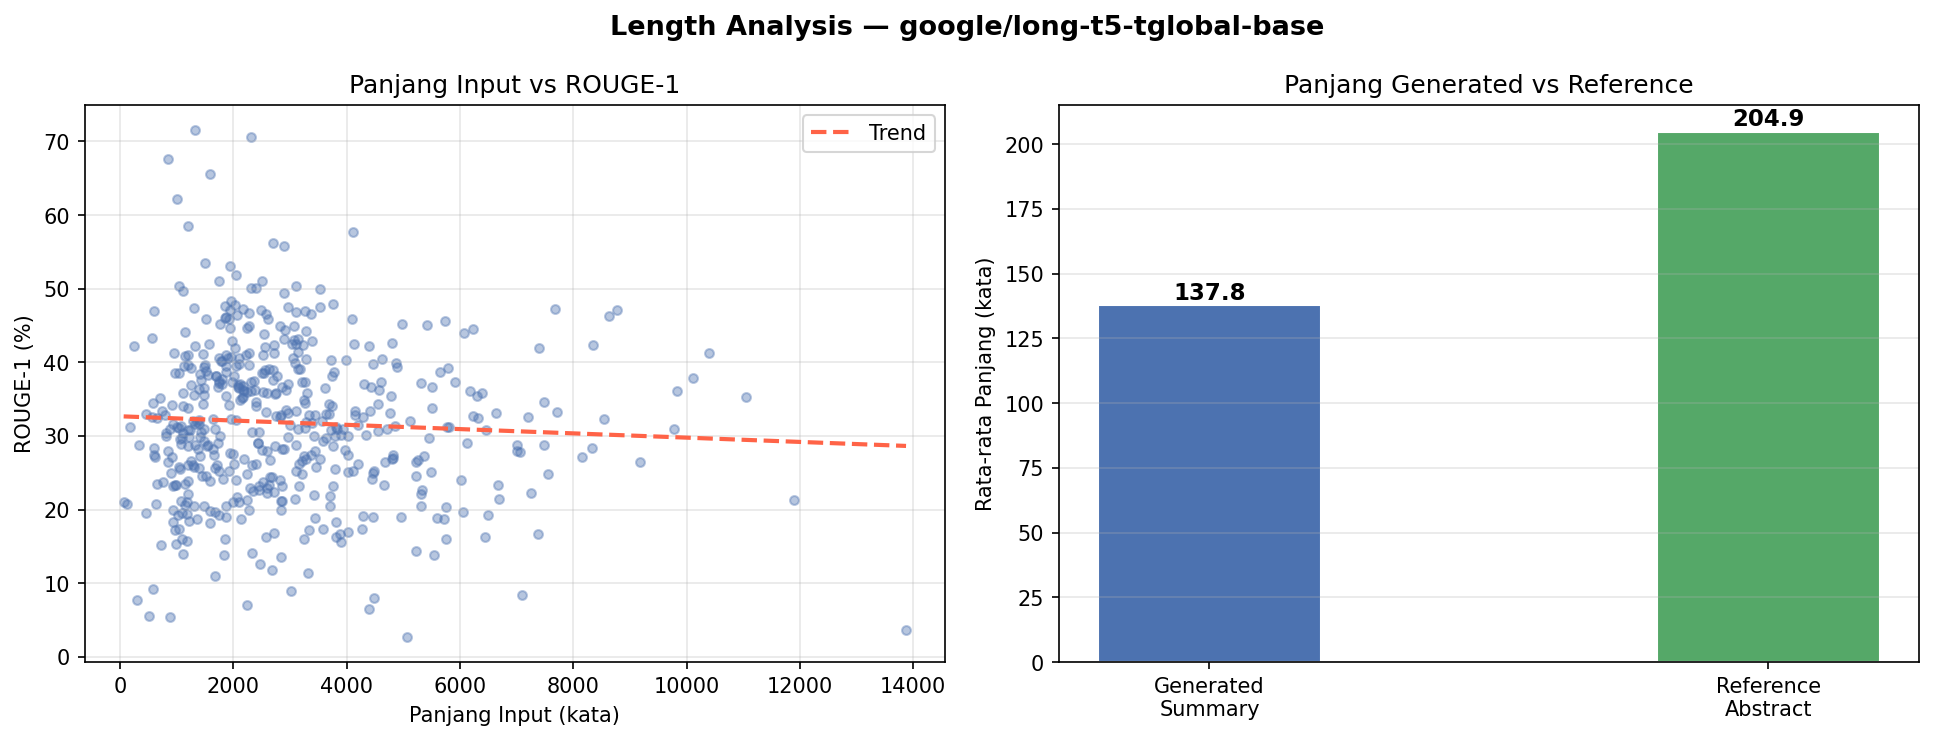


📊 Rouge Bar Hist


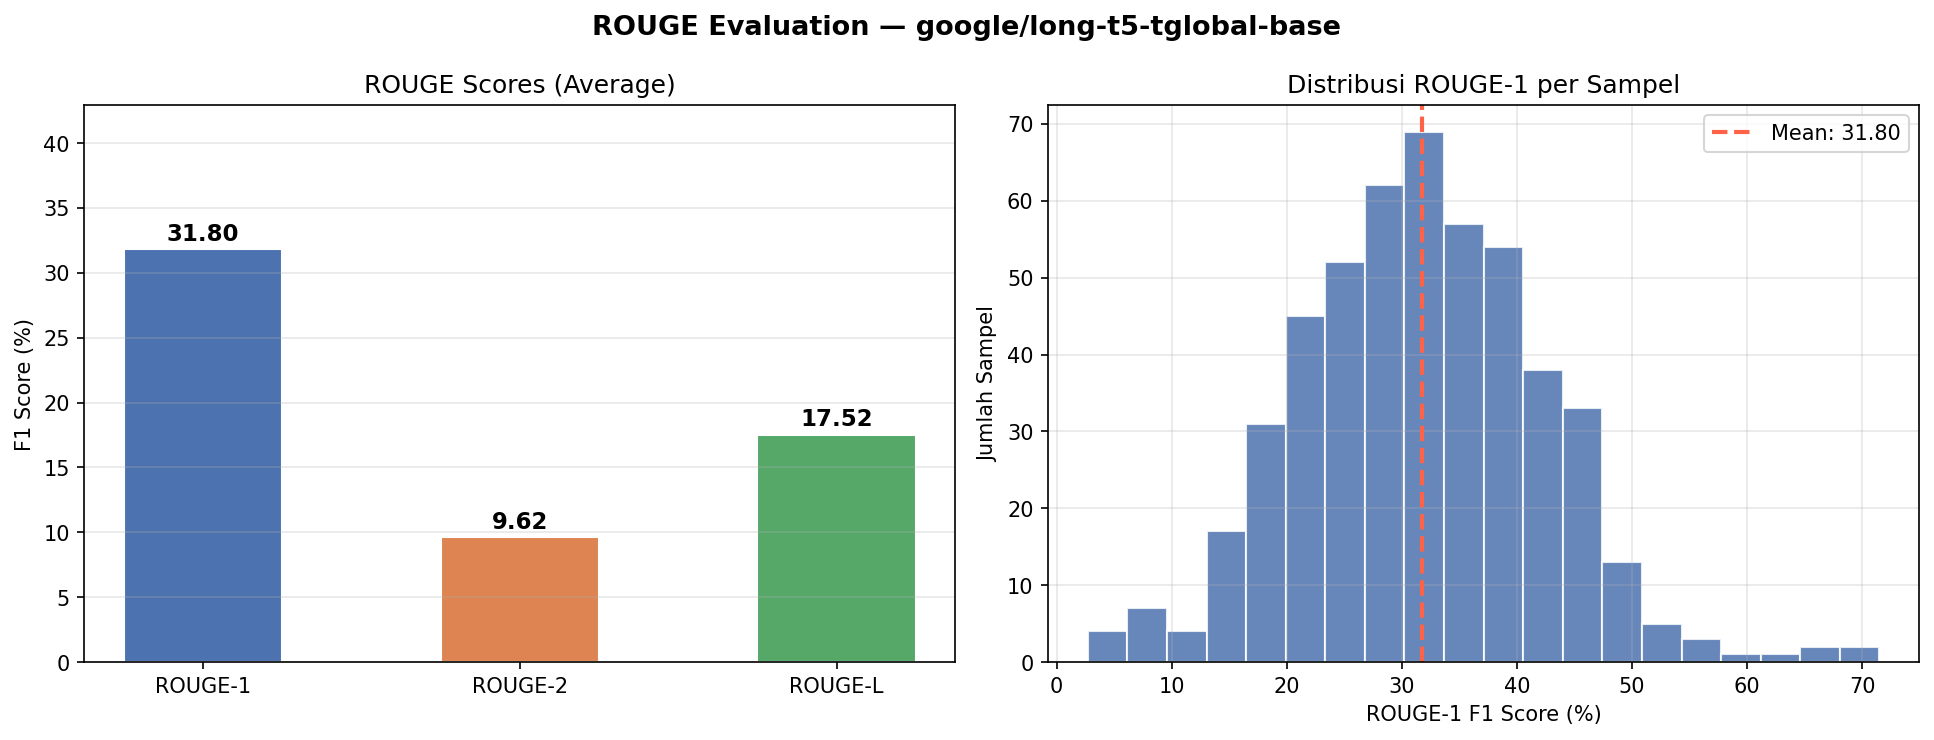


📊 Rouge Boxplot


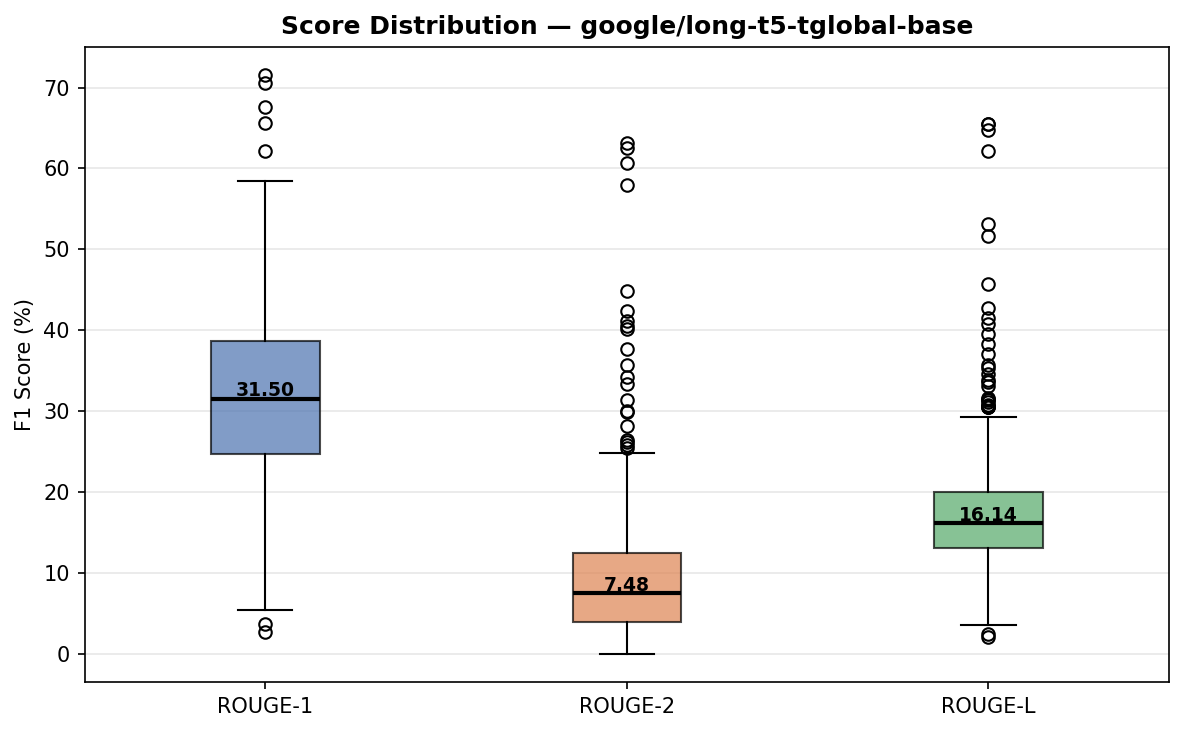


📊 Training Curves


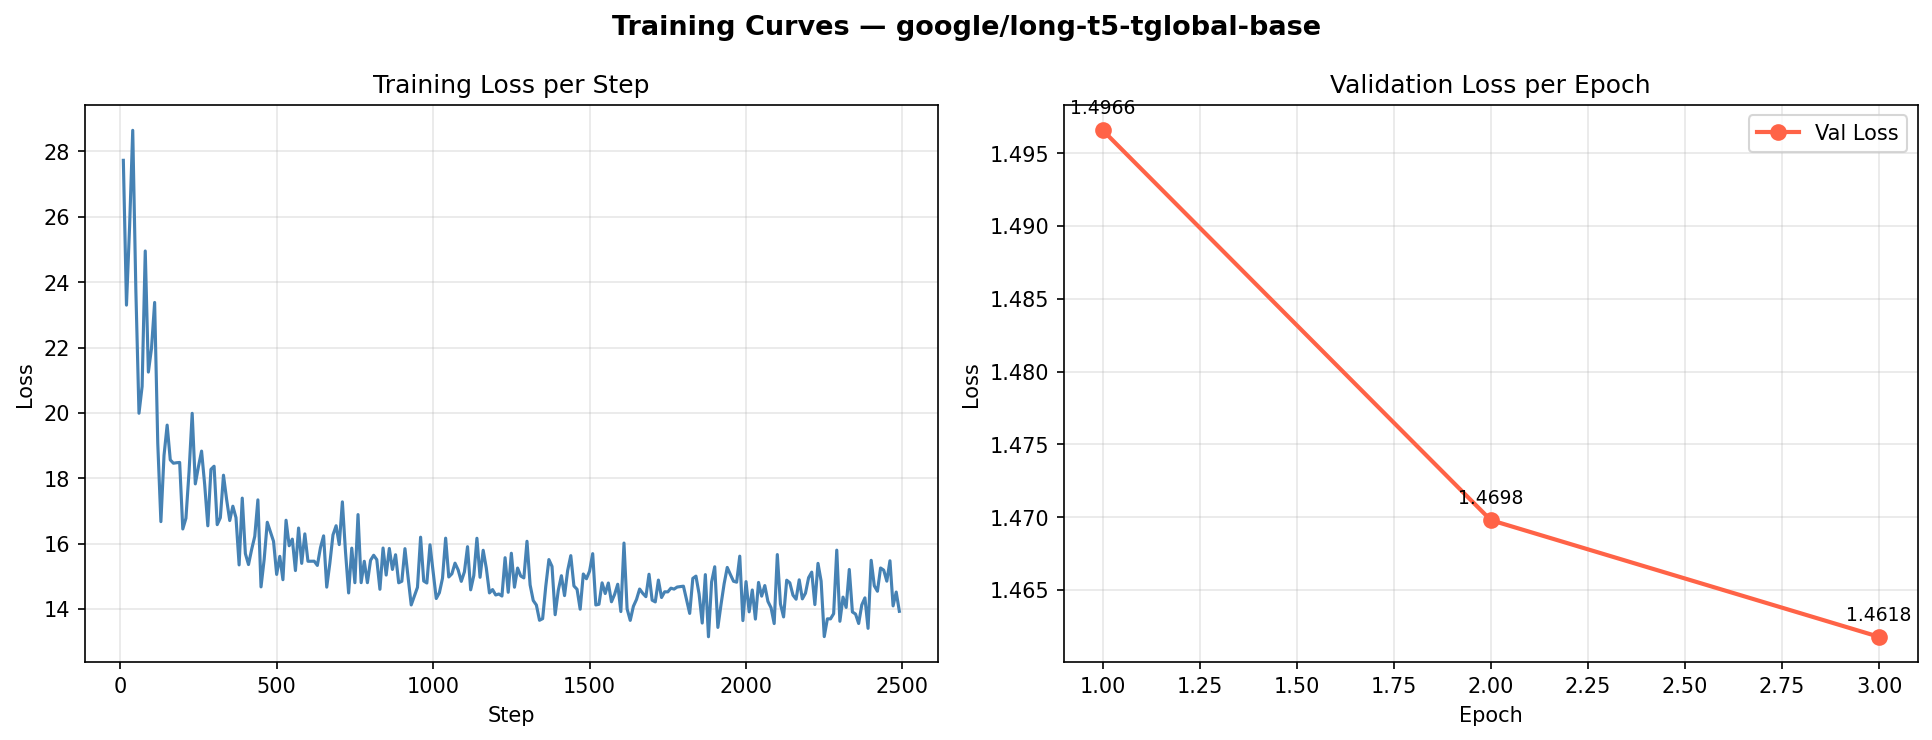

In [33]:
from IPython.display import display, Image
import glob

# ── Tampilkan semua visualisasi ──
viz_files = sorted(glob.glob('./viz_*.png'))

print(f"Total visualisasi: {len(viz_files)}")
print("=" * 50)

for f in viz_files:
    name = f.replace('./viz_', '').replace('.png', '').replace('_', ' ').title()
    print(f"\n📊 {name}")
    display(Image(filename=f, width=900))